In [2]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

# initialize the seeds of different random number generators so that the
# results will be the same every time the notebook is run
keras.utils.set_random_seed(42)

TensorFlow Version: 2.18.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Clean up any broken attempt and download using curl
!rm -f fer2013.csv
!curl -Lo fer2013.csv "https://dl.dropbox.com/scl/fi/e2ik6aryemboameq1rwwn/fer2013.csv?rlkey=ux7tyge6flk9nnuul9desizgf&dl=1"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   196    0   196    0     0      0      0 --:--:-- --:--:-- --:--:--     0  0   1291      0 --:--:-- --:--:-- --:--:--  1298
100  287M  100  287M    0     0  31.1M      0  0:00:09  0:00:09 --:-0:01 35.5M-:-- 35.2M


In [4]:
data = pd.read_csv('fer2013.csv')
data

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training
...,...,...,...
35882,6,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,PrivateTest
35883,3,178 174 172 173 181 188 191 194 196 199 200 20...,PrivateTest
35884,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,PrivateTest
35885,3,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,PrivateTest


In [5]:
len(data.loc[0, 'pixels'].split(' '))

2304

In [6]:
pixels = data['pixels'].tolist()
width, height = 48, 48
faces = []
for pixel_sequence in pixels:
        face = [int(pixels) for pixels in pixel_sequence.split(' ')] # read each face as a 1-d array
        face = np.asarray(face).reshape(width, height) # reshape the length 2304 1-d array into an 48x48 array
        face = np.stack((face,)*3, axis=-1)
        faces.append(face.astype('float32'))

faces = np.asarray(faces)
faces.shape

(35887, 48, 48, 3)

In [7]:
faces[0, :, :, 0]

array([[ 70.,  80.,  82., ...,  52.,  43.,  41.],
       [ 65.,  61.,  58., ...,  56.,  52.,  44.],
       [ 50.,  43.,  54., ...,  49.,  56.,  47.],
       ...,
       [ 91.,  65.,  42., ...,  72.,  56.,  43.],
       [ 77.,  82.,  79., ..., 105.,  70.,  46.],
       [ 77.,  72.,  84., ..., 106., 109.,  82.]], dtype=float32)

In [8]:
faces[0, :, :, 1]

array([[ 70.,  80.,  82., ...,  52.,  43.,  41.],
       [ 65.,  61.,  58., ...,  56.,  52.,  44.],
       [ 50.,  43.,  54., ...,  49.,  56.,  47.],
       ...,
       [ 91.,  65.,  42., ...,  72.,  56.,  43.],
       [ 77.,  82.,  79., ..., 105.,  70.,  46.],
       [ 77.,  72.,  84., ..., 106., 109.,  82.]], dtype=float32)

In [9]:
data.emotion.unique()

array([0, 2, 4, 6, 3, 5, 1])

In [10]:
emotions = pd.get_dummies(data['emotion']).to_numpy() # each emotion is 'one-hot' encoded as a 7-dim vector
emotions_names = ('angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral')
emotions.shape

(35887, 7)

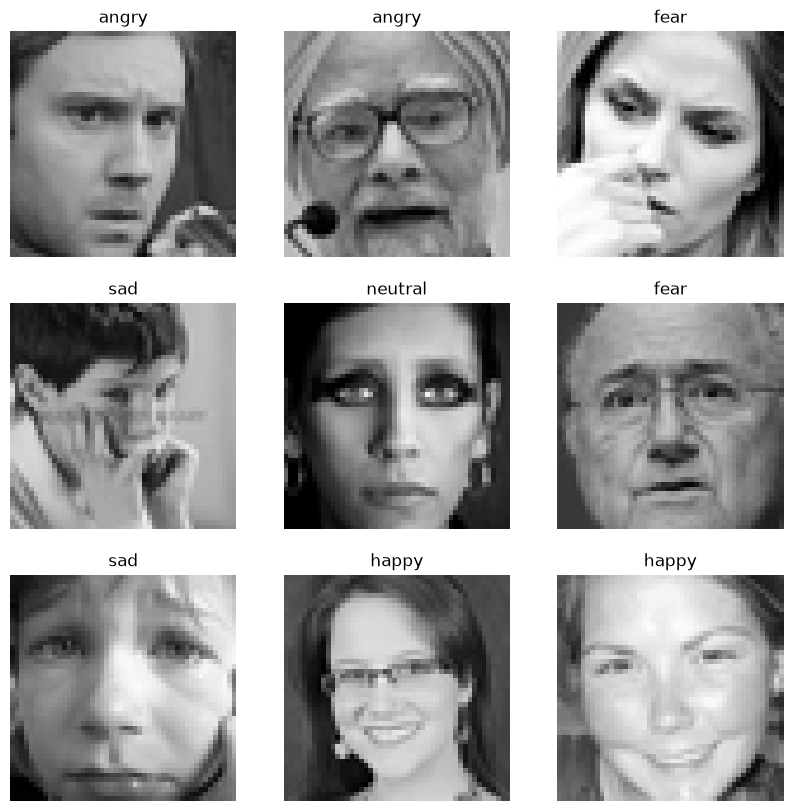

In [11]:
fig = plt.figure(figsize=(10, 10))
for i in range(9):
    ax = fig.add_subplot(3, 3, i+1)
    ax.set_title(f"{emotions_names[np.argmax(emotions[i])]}")
    ax.imshow(faces[i].astype('uint8'))
    ax.axis('off')

In [12]:
train_faces, train_emotions = faces[:28709], emotions[:28709]
test_faces, test_emotions = faces[28709:], emotions[28709:]

train_faces.shape, train_emotions.shape, test_faces.shape, test_emotions.shape

((28709, 48, 48, 3), (28709, 7), (7178, 48, 48, 3), (7178, 7))

In [13]:
# 1. Input Layer: (48, 48, 3)
input_layer = keras.Input(shape=(48, 48, 3), name='input')

###### YOUR CODE HERE #####

# 2. Rescaling Layer: Scales inputs to [0, 1]
x = keras.layers.Rescaling(scale=1.0 / 255.0, name='rescaling_1')(input_layer)

# 3. Conv2D Layer 1: Output shape (47, 47, 16) with 208 parameters
x = keras.layers.Conv2D(16, kernel_size=(2, 2), activation='relu', name='Conv_1')(x)

# 4. MaxPooling2D Layer: Output shape (23, 23, 16)
x = keras.layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), name='max_pooling2d_3')(x)

# 5. Conv2D Layer 2: Output shape (22, 22, 16) with 1040 parameters
x = keras.layers.Conv2D(16, kernel_size=(2, 2), activation='relu', name='Conv_2')(x)

# 6. MaxPooling2D Layer: Output shape (11, 11, 16)
x = keras.layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), name='max_pooling2d_4')(x)

# 7. Conv2D Layer 2: Output shape (10, 10, 16) with 1040 parameters
x = keras.layers.Conv2D(16, kernel_size=(2, 2), activation='relu', name='Conv_3')(x)

# 8. MaxPooling2D Layer: Output shape (5, 5, 16)
x = keras.layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), name='max_pooling2d_5')(x)

# 9. Flatten Layer
x = keras.layers.Flatten()(x)

# 10. fully-connected (dense) ReLU layer
x = keras.layers.Dense(256, activation='relu')(x)

# 11. output softmax layer
output = keras.layers.Dense(7, activation='softmax')(x)

###### YOUR CODE HERE #####

model = keras.Model(input_layer, output, name='CNN_model')
model.summary()

2026-07-22 18:27:16.522453: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-07-22 18:27:16.522580: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-22 18:27:16.522590: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
I0000 00:00:1784770036.523127 13984228 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1784770036.523169 13984228 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "CNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 47, 47, 16)     │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 22, 22, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 11, 11, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 10, 10, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       102,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,743 (416.96 KB)

 Trainable params: 106,743 (416.96 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_history = model.fit(train_faces, train_emotions, batch_size=64, epochs=30, validation_split=0.2)

Epoch 1/30


2026-07-22 18:27:17.474943: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


359/359 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.3010 - loss: 1.7313 - val_accuracy: 0.3708 - val_loss: 1.6432
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.3815 - loss: 1.5874 - val_accuracy: 0.4127 - val_loss: 1.5570
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4119 - loss: 1.5245 - val_accuracy: 0.4375 - val_loss: 1.5021
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4376 - loss: 1.4749 - val_accuracy: 0.4500 - val_loss: 1.4636
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4519 - loss: 1.4474 - val_accuracy: 0.4488 - val_loss: 1.4496
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4563 - loss: 1.4356 - val_accuracy: 0.4476 - val_loss: 1.4933
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4533 - loss: 1.4501 - val_accuracy: 0.4307 - val_loss: 1.5418
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4363 - loss: 1.5266 - val_accuracy: 0.387

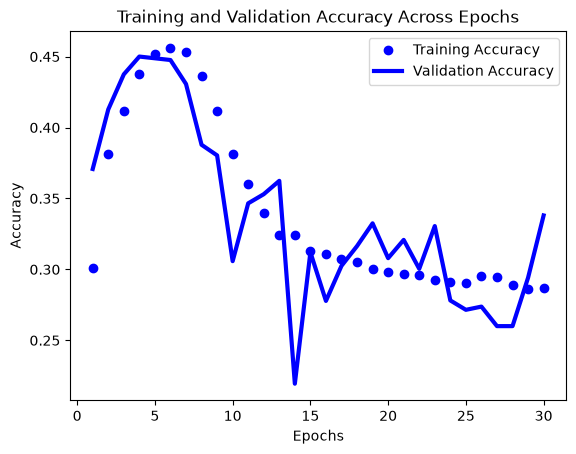

In [15]:
def plot_accuracy(model_history):
    history_dict = model_history.history
    acc = history_dict["accuracy"]
    val_acc = history_dict["val_accuracy"]
    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, "bo", label="Training Accuracy", linewidth=3)
    plt.plot(epochs, val_acc, "b", label="Validation Accuracy", linewidth=3)
    plt.title("Training and Validation Accuracy Across Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_accuracy(model_history)

In [16]:
score = model.evaluate(test_faces, test_emotions)
print("Test accuracy:", score[1])

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3314 - loss: 465.6414
Test accuracy: 0.3314293622970581


In [17]:
# 1. Input Layer: (48, 48, 3)
input_layer = keras.Input(shape=(48, 48, 3), name='input')

###### YOUR CODE HERE #####

# 2. Rescaling Layer: Scales inputs to [0, 1]
x = keras.layers.Rescaling(scale=1.0 / 255.0, name='rescaling_1')(input_layer)

# 3. Conv2D Layer 1: Output shape (47, 47, 32) with 416 parameters
x = keras.layers.Conv2D(32, kernel_size=(2, 2), activation='relu', name='Conv_1')(x)

# 4. MaxPooling2D Layer: Output shape (23, 23, 32)
x = keras.layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), name='max_pooling2d_3')(x)

# 5. Conv2D Layer 2: Output shape (22, 22, 32) with 2080 parameters
x = keras.layers.Conv2D(32, kernel_size=(2, 2), activation='relu', name='Conv_2')(x)

# 6. MaxPooling2D Layer: Output shape (11, 11, 32)
x = keras.layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), name='max_pooling2d_4')(x)

# 7. Conv2D Layer 2: Output shape (10, 10, 16) with 2080 parameters
x = keras.layers.Conv2D(32, kernel_size=(2, 2), activation='relu', name='Conv_3')(x)

# 8. MaxPooling2D Layer: Output shape (5, 5, 16)
x = keras.layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), name='max_pooling2d_5')(x)

# 9. Flatten Layer
x = keras.layers.Flatten()(x)

# 10. fully-connected (dense) ReLU layer
x = keras.layers.Dense(256, activation='relu')(x)

# 11. output softmax layer
output = keras.layers.Dense(7, activation='softmax')(x)

###### YOUR CODE HERE #####

wider_model = keras.Model(input_layer, output, name='CNN_model')
wider_model.summary()

Model: "CNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 47, 47, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 22, 22, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 10, 10, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,527 (841.90 KB)

 Trainable params: 215,527 (841.90 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
wider_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

wider_model_history = wider_model.fit(train_faces, train_emotions, batch_size=64, epochs=30, validation_split=0.2)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.3184 - loss: 1.7001 - val_accuracy: 0.3955 - val_loss: 1.5750
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.4217 - loss: 1.5131 - val_accuracy: 0.4467 - val_loss: 1.4675
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4537 - loss: 1.4359 - val_accuracy: 0.4680 - val_loss: 1.4278
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4710 - loss: 1.3972 - val_accuracy: 0.4798 - val_loss: 1.4136
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4794 - loss: 1.3890 - val_accuracy: 0.4725 - val_loss: 1.4339
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4741 - loss: 1.4278 - val_accuracy: 0.4547 - val_loss: 1.5279
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4597 - loss: 1.5355 - val_accuracy: 0.4094 - val_loss: 1.8746
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4346 - loss: 1.7797 - val_accu

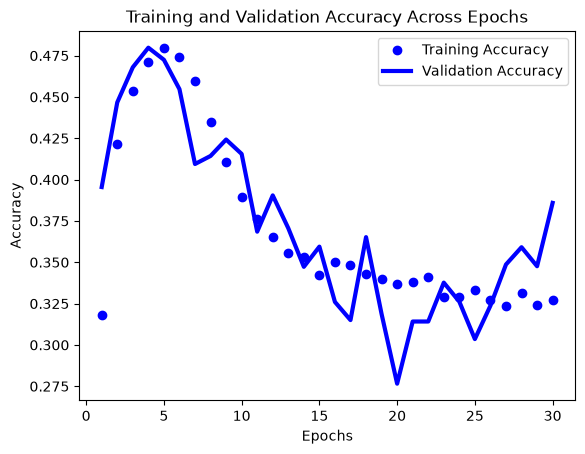

In [19]:
plot_accuracy(wider_model_history)

In [20]:
score = wider_model.evaluate(test_faces, test_emotions)
print("Test accuracy:", score[1])

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3732 - loss: 1095.6406
Test accuracy: 0.37322375178337097


In [21]:
# 1. Input Layer: (48, 48, 3)
input_layer = keras.Input(shape=(48, 48, 3), name='input')

###### YOUR CODE HERE #####

# 2. Rescaling Layer: Scales inputs to [0, 1]
x = keras.layers.Rescaling(scale=1.0 / 255.0, name='rescaling_1')(input_layer)

# 3. Conv2D Layer 1: Output shape (47, 47, 16) with 208 parameters
x = keras.layers.Conv2D(16, kernel_size=(2, 2), activation='relu', name='Conv_1')(x)

# 4. MaxPooling2D Layer: Output shape (23, 23, 16)
x = keras.layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), name='max_pooling2d_3')(x)

# 5. Conv2D Layer 2: Output shape (22, 22, 16) with 1040 parameters
x = keras.layers.Conv2D(16, kernel_size=(2, 2), activation='relu', name='Conv_2')(x)

# 6. MaxPooling2D Layer: Output shape (11, 11, 16)
x = keras.layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), name='max_pooling2d_4')(x)

# 7. Conv2D Layer 2: Output shape (10, 10, 16) with 1040 parameters
x = keras.layers.Conv2D(16, kernel_size=(2, 2), activation='relu', name='Conv_3')(x)

# 8. MaxPooling2D Layer: Output shape (5, 5, 16)
x = keras.layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), name='max_pooling2d_5')(x)

# 9. Flatten Layer
x = keras.layers.Flatten()(x)

# 10. fully-connected (dense) ReLU layer
x = keras.layers.Dense(256, activation='relu')(x)

# 11. fully-connected (dense) ReLU layer
x = keras.layers.Dense(256, activation='relu')(x)

# 12. output softmax layer
output = keras.layers.Dense(7, activation='softmax')(x)

###### YOUR CODE HERE #####

deeper_model = keras.Model(input_layer, output, name='CNN_model')
deeper_model.summary()

Model: "CNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 47, 47, 16)     │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 22, 22, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 11, 11, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 10, 10, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       102,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,535 (673.96 KB)

 Trainable params: 172,535 (673.96 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
deeper_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

deeper_model_history = wider_model.fit(train_faces, train_emotions, batch_size=64, epochs=30, validation_split=0.2)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3209 - loss: 1570.7727 - val_accuracy: 0.2778 - val_loss: 1829.6040
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3263 - loss: 1759.3898 - val_accuracy: 0.3029 - val_loss: 2026.6442
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3249 - loss: 2162.4497 - val_accuracy: 0.3612 - val_loss: 2160.0723
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3249 - loss: 2282.3364 - val_accuracy: 0.3389 - val_loss: 2595.7524
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3215 - loss: 2819.2737 - val_accuracy: 0.3567 - val_loss: 2381.4602
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3219 - loss: 3230.9060 - val_accuracy: 0.3433 - val_loss: 3302.5403
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3214 - loss: 3703.3154 - val_accuracy: 0.3443 - val_loss: 4088.9814
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - 

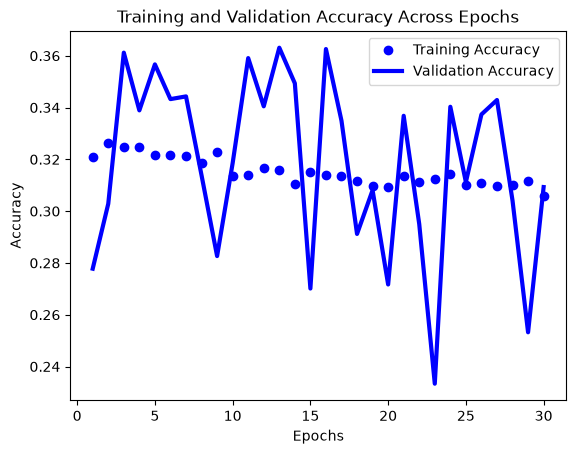

In [23]:
plot_accuracy(deeper_model_history)

In [24]:
score = deeper_model.evaluate(test_faces, test_emotions)
print("Test accuracy:", score[1])

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1565 - loss: 1.9386
Test accuracy: 0.1564502716064453


In [25]:
%pip install pillow

Note: you may need to restart the kernel to use updated packages.


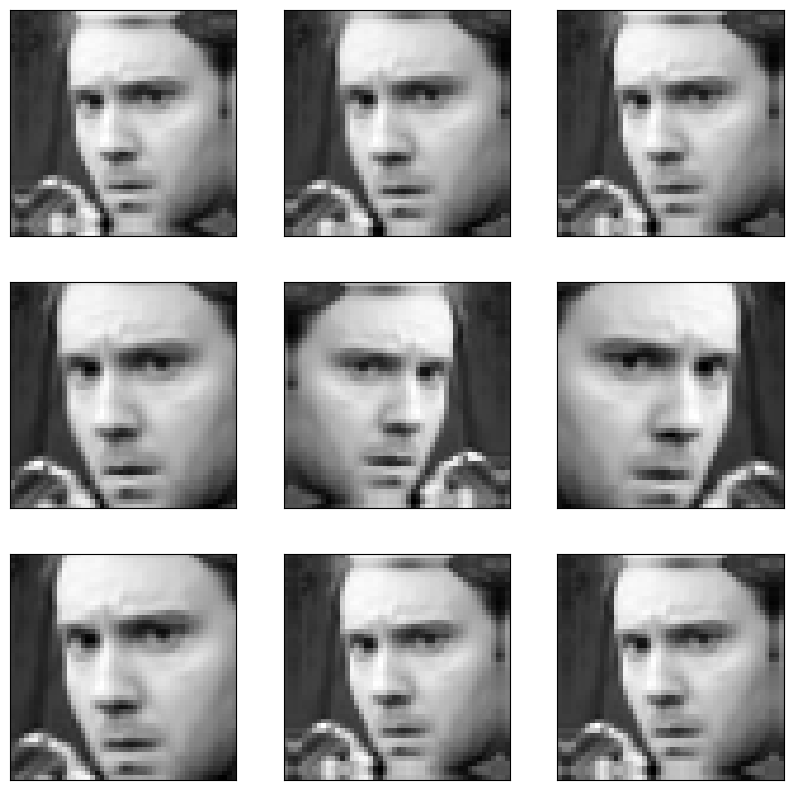

In [26]:
def augment_images(image):
    x = keras.layers.RandomFlip('horizontal')(image)
    x = keras.layers.RandomZoom(0.2)(x)
    return x

augmented_images = [augment_images(np.expand_dims(train_faces[0], axis=0)) for i in range(9)]
fig = plt.figure(figsize=(10, 10))
for i in range(9):
    ax = fig.add_subplot(3, 3, i+1, xticks=[], yticks=[])
    ax.imshow(tf.keras.preprocessing.image.array_to_img(augmented_images[i][0]), cmap='gray', vmin=0, vmax=255)

In [27]:
# 1. Input Layer: (48, 48, 3)
input_layer = keras.Input(shape=(48, 48, 3), name='input')

### DATA AUGMENTATION ###
x = keras.layers.RandomFlip("horizontal")(input_layer)
x = keras.layers.RandomZoom(0.2)(x)

### YOUR CODE HERE ###

# 2. Rescaling Layer: Scales inputs to [0, 1]
x = keras.layers.Rescaling(scale=1.0 / 255.0, name='rescaling_1')(input_layer)

# 3. Conv2D Layer 1: Output shape (47, 47, 32) with 416 parameters
x = keras.layers.Conv2D(32, kernel_size=(2, 2), activation='relu', name='Conv_1')(x)

# 4. MaxPooling2D Layer: Output shape (23, 23, 32)
x = keras.layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), name='max_pooling2d_3')(x)

# 5. Conv2D Layer 2: Output shape (22, 22, 32) with 2080 parameters
x = keras.layers.Conv2D(32, kernel_size=(2, 2), activation='relu', name='Conv_2')(x)

# 6. MaxPooling2D Layer: Output shape (11, 11, 32)
x = keras.layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), name='max_pooling2d_4')(x)

# 7. Conv2D Layer 2: Output shape (10, 10, 16) with 2080 parameters
x = keras.layers.Conv2D(32, kernel_size=(2, 2), activation='relu', name='Conv_3')(x)

# 8. MaxPooling2D Layer: Output shape (5, 5, 16)
x = keras.layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), name='max_pooling2d_5')(x)

# 9. Flatten Layer
x = keras.layers.Flatten()(x)

# 10. fully-connected (dense) ReLU layer
x = keras.layers.Dense(256, activation='relu')(x)

# 11. output softmax layer
output = keras.layers.Dense(7, activation='softmax')(x)

model_augmented = keras.Model(input_layer, output, name='augmented_CNN_model')
model_augmented.summary()

Model: "augmented_CNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 47, 47, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 22, 22, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 10, 10, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,527 (841.90 KB)

 Trainable params: 215,527 (841.90 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model_augmented.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_augmented_history = model_augmented.fit(train_faces, train_emotions, batch_size=64, epochs=30, validation_split=0.2)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.3081 - loss: 1.7157 - val_accuracy: 0.3967 - val_loss: 1.5718
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4181 - loss: 1.5170 - val_accuracy: 0.4418 - val_loss: 1.4692
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4584 - loss: 1.4209 - val_accuracy: 0.4667 - val_loss: 1.4268
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4785 - loss: 1.3767 - val_accuracy: 0.4655 - val_loss: 1.4377
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4823 - loss: 1.3818 - val_accuracy: 0.4511 - val_loss: 1.4807
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4692 - loss: 1.4445 - val_accuracy: 0.4251 - val_loss: 1.7136
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4415 - loss: 1.6407 - val_accuracy: 0.4140 - val_loss: 2.1256
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4158 - loss: 2.1258 - val_accu

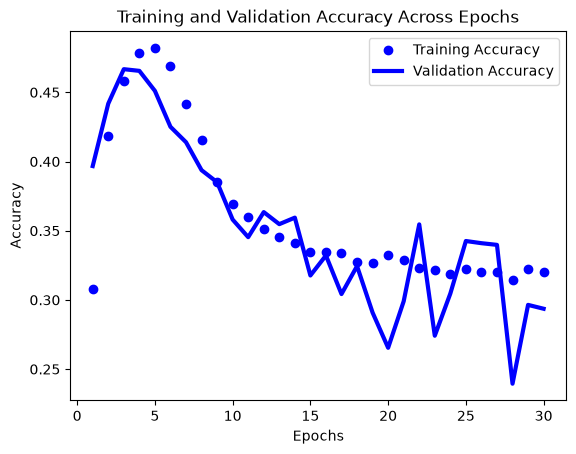

In [29]:
plot_accuracy(model_augmented_history)

In [30]:
score = model_augmented.evaluate(test_faces, test_emotions)
print("Test accuracy:", score[1])

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2924 - loss: 4248.7280
Test accuracy: 0.29242128133773804


In [31]:
base_model = keras.applications.VGG19(
    include_top=False, # this makes VGG19 headless
    weights= 'imagenet',
    input_tensor=None,
    input_shape=(48, 48, 3),
    pooling=None,
    classes=1000,
    classifier_activation='softmax',
)

# Freeze the base_model so that it is not trainable at all
base_model.trainable = False

In [32]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Load VGG19 without its top classification layers
base_model = keras.applications.VGG19(
    weights='imagenet',
    include_top=False,          # Exclude the original 1000-class head
    input_shape=(48, 48, 3)
)

# Freeze the VGG19 base model so we only train the new dense head
base_model.trainable = False

# 2. Input Layer
inputs = keras.Input(shape=(48, 48, 3), name='input')

# 3. Data Augmentation
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomZoom(0.2)(x)

# 4. Rescaling Layer
x = layers.Rescaling(1.0 / 255.0)(x)

# 5. Pass through VGG19 backbone
x = base_model(x, training=False)

# 6. Flatten feature maps
x = layers.Flatten()(x)

# 7. One Dense Layer
x = layers.Dense(256, activation='relu')(x)

# 8. Output Layer (7 emotion classes)
outputs = layers.Dense(7, activation='softmax')(x)

# Build Model
vgg19_model = keras.Model(inputs, outputs, name='vgg19_transfer_model')

vgg19_model.summary()

Model: "vgg19_transfer_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_10 (RandomFlip)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_10 (RandomZoom)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 1, 1, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,157,511 (76.89 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [33]:
vgg19_model.compile(loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(2e-5),
            metrics=['accuracy'])

vgg19_model_history = vgg19_model.fit(train_faces, train_emotions, epochs=30, validation_split=0.2)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.2544 - loss: 1.8166 - val_accuracy: 0.2947 - val_loss: 1.7441
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3023 - loss: 1.7352 - val_accuracy: 0.3253 - val_loss: 1.6988
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3146 - loss: 1.7065 - val_accuracy: 0.3366 - val_loss: 1.6756
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3250 - loss: 1.6877 - val_accuracy: 0.3434 - val_loss: 1.6617
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.3301 - loss: 1.6766 - val_accuracy: 0.3480 - val_loss: 1.6515
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.3347 - loss: 1.6685 - val_accuracy: 0.3530 - val_loss: 1.6429
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3383 - loss: 1.6639 - val_accuracy: 0.3551 - val_loss: 1.6360
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3388 - loss: 1.6564 - 

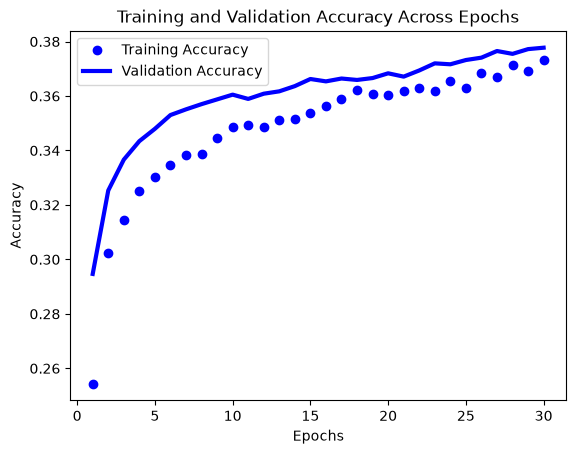

In [34]:
plot_accuracy(vgg19_model_history)

225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step
*************************
* Test Accuracy: 0.3656 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,117,0,51,459,100,67,164
disgust,13,0,13,50,15,9,11
fear,47,0,133,405,135,154,150
happy,65,0,50,1313,103,53,190
sad,101,0,95,545,261,30,215
surprise,31,0,64,186,24,408,118
neutral,75,0,55,555,93,63,392


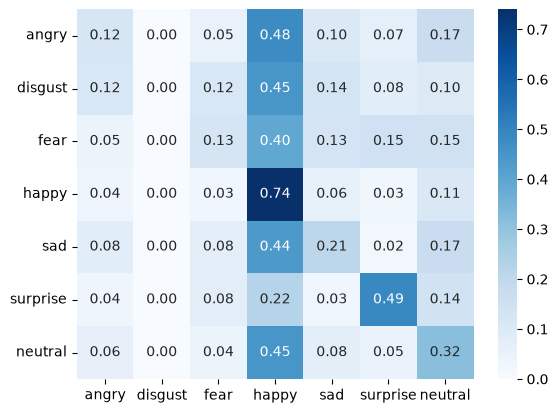

In [35]:
from IPython.display import display

def show_confusion_matrix(model):
    """
    Calculates the test accuracy, confusion matrix and heat map for a model.
    """
    global test_faces, test_emotions, emotions_names

    y_pred = model.predict(test_faces).argmax(axis=1)
    y_actual = test_emotions.argmax(axis=1)

    print('*************************\n* Test Accuracy: %.4f *\n*************************' % metrics.accuracy_score(y_actual, y_pred))

    cm = pd.DataFrame(metrics.confusion_matrix(y_actual, y_pred), index=emotions_names, columns=emotions_names)
    display(cm)

    cm = cm.div(cm.sum(axis=1), axis=0)

    sns.heatmap(cm, cmap="Blues", annot=True, fmt=".2f")

show_confusion_matrix(vgg19_model)

In [36]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Devices Found:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.18.0
GPU Devices Found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [37]:
import keras

base_model = keras.applications.VGG19(
    include_top=False,   # headless
    weights="imagenet",
    input_shape=(48, 48, 3) # Specify input shape directly in the base model
)

inputs = keras.Input(shape=(48, 48, 3))

x = keras.layers.RandomFlip("horizontal")(inputs)
x = keras.layers.RandomZoom(0.2)(x)
x = keras.layers.Rescaling(1./255)(x)

# Pass x directly through base_model instead of looping over layers
x = base_model(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs = keras.layers.Dense(7, activation='softmax')(x)

partial_model = keras.Model(inputs, outputs, name='partial_fine_tune_model')

# Freeze the base_model or specific layers within base_model
base_model.trainable = False  # Freezes all VGG19 layers at once

partial_model.summary()

Model: "partial_fine_tune_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_11 (RandomFlip)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_11 (RandomZoom)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 1, 1, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,157,511 (76.89 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [38]:
for i, layer in enumerate(partial_model.layers):
    print('Layer %d: %s (%s), Trainable=%s' % (i+1, layer.name, layer.__class__.__name__, layer.trainable))

Layer 1: input_layer_3 (InputLayer), Trainable=True
Layer 2: random_flip_11 (RandomFlip), Trainable=True
Layer 3: random_zoom_11 (RandomZoom), Trainable=True
Layer 4: rescaling_1 (Rescaling), Trainable=True
Layer 5: vgg19 (Functional), Trainable=False
Layer 6: flatten_5 (Flatten), Trainable=True
Layer 7: dense_11 (Dense), Trainable=True
Layer 8: dense_12 (Dense), Trainable=True


In [39]:
partial_model.compile(loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(2e-5),
            metrics=['accuracy'])

partial_model_history = partial_model.fit(train_faces, train_emotions, epochs=30, validation_split=0.2)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - accuracy: 0.2229 - loss: 1.9193 - val_accuracy: 0.2793 - val_loss: 1.7663
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.2943 - loss: 1.7440 - val_accuracy: 0.3150 - val_loss: 1.7133
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.3164 - loss: 1.7126 - val_accuracy: 0.3253 - val_loss: 1.6856
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.3197 - loss: 1.6940 - val_accuracy: 0.3358 - val_loss: 1.6684
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.3286 - loss: 1.6823 - val_accuracy: 0.3440 - val_loss: 1.6564
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.3344 - loss: 1.6740 - val_accuracy: 0.3469 - val_loss: 1.6477
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.3369 - loss: 1.6656 - val_accuracy: 0.3542 - val_loss: 1.6393
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.3419 - loss: 1.6571 - 